1. Load Data and IP Mapping

In [1]:
import pandas as pd
import numpy as np
import ipaddress
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/fraud_data_cleaned.csv')
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# Load IP to country mapping
ip_mapping = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print("Fraud Data Shape:", df.shape)
print("IP Mapping Shape:", ip_mapping.shape)
df.head()

Fraud Data Shape: (151112, 14)
IP Mapping Shape: (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,hour,day_of_week,month
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,2,5,4
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,1,0,6
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,18,3,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,13,0,5
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,18,2,9


2. IP to Integer Conversion Function

In [2]:
def ip_to_int(ip_string):
    """Convert IP address string to integer"""
    try:
        return int(ipaddress.IPv4Address(ip_string))
    except:
        return None

# Test the function
test_ip = '192.168.1.1'
print(f"IP: {test_ip} -> Integer: {ip_to_int(test_ip)}")

IP: 192.168.1.1 -> Integer: 3232235777


3. Convert IP Ranges

In [3]:
# Convert IP ranges to integers
ip_mapping['lower_int'] = ip_mapping['lower_bound_ip_address'].apply(ip_to_int)
ip_mapping['upper_int'] = ip_mapping['upper_bound_ip_address'].apply(ip_to_int)

# Convert transaction IPs
df['ip_int'] = df['ip_address'].apply(ip_to_int)

# Remove any rows with failed IP conversion
df = df.dropna(subset=['ip_int'])
ip_mapping = ip_mapping.dropna(subset=['lower_int', 'upper_int'])

print(f"After cleaning: {len(df)} transactions, {len(ip_mapping)} IP ranges")

After cleaning: 0 transactions, 0 IP ranges


4. Perform IP to Country Mapping

In [25]:
# Debug IP Mapping Conversion


import pandas as pd
import numpy as np
import ipaddress

print("Step 1: Checking IP address format in transactions...")
print(f"IP column type: {df['ip_address'].dtype}")
print(f"Sample IP values: {df['ip_address'].head(3).tolist()}")

# IPs are already numbers - convert to integer
print("\nStep 2: Converting transaction IPs to integers...")
df['ip_int'] = df['ip_address'].astype('int64')
df_clean = df[df['ip_int'] > 0].copy()
print(f"  - Valid transactions: {len(df_clean)}")

print("\nStep 3: Checking IP mapping file...")
print(f"IP Mapping shape: {ip_mapping.shape}")
print(f"IP Mapping columns: {ip_mapping.columns.tolist()}")
print(f"\nFirst 5 rows of IP mapping:")
print(ip_mapping.head())

print("\nStep 4: Testing IP conversion on mapping data...")

def ip_str_to_int(ip_string):
    """Convert IP string to integer with detailed error handling"""
    try:
        if pd.isna(ip_string):
            return None
        # Convert to string and strip
        ip_str = str(ip_string).strip()
        # Handle if it's already a number
        if ip_str.replace('.', '').isdigit():
            return int(float(ip_str))
        return int(ipaddress.IPv4Address(ip_str))
    except Exception as e:
        print(f"  Failed on: {ip_string} - Error: {e}")
        return None

# Test on first few rows
test_ips = ip_mapping['lower_bound_ip_address'].head(5)
print("\nTesting IP conversion on first 5 lower bounds:")
for ip in test_ips:
    result = ip_str_to_int(ip)
    print(f"  {ip} -> {result}")

print("\nStep 5: Converting all IP ranges...")
ip_mapping['lower_int'] = ip_mapping['lower_bound_ip_address'].apply(ip_str_to_int)
ip_mapping['upper_int'] = ip_mapping['upper_bound_ip_address'].apply(ip_str_to_int)

# Count valid conversions
valid_lower = ip_mapping['lower_int'].notna().sum()
valid_upper = ip_mapping['upper_int'].notna().sum()
print(f"  - Valid lower_int: {valid_lower} out of {len(ip_mapping)}")
print(f"  - Valid upper_int: {valid_upper} out of {len(ip_mapping)}")

# Remove NaN values
ip_mapping_clean = ip_mapping.dropna(subset=['lower_int', 'upper_int']).copy()
print(f"  - Clean IP ranges after dropping NaN: {len(ip_mapping_clean)}")

if len(ip_mapping_clean) > 0:
    # Convert to int64
    ip_mapping_clean['lower_int'] = ip_mapping_clean['lower_int'].astype('int64')
    ip_mapping_clean['upper_int'] = ip_mapping_clean['upper_int'].astype('int64')
    print(f"\n✓ Success! Converted {len(ip_mapping_clean)} IP ranges")
    print(f"  - Lower range: {ip_mapping_clean['lower_int'].min()} to {ip_mapping_clean['lower_int'].max()}")
    print(f"  - Upper range: {ip_mapping_clean['upper_int'].min()} to {ip_mapping_clean['upper_int'].max()}")
else:
    print("\n❌ Failed to convert any IP ranges!")
    print("Checking if column names are correct...")
    print(f"Available columns: {ip_mapping.columns.tolist()}")
    
    # Try alternative column names
    possible_ip_cols = [col for col in ip_mapping.columns if 'ip' in col.lower()]
    print(f"Possible IP columns: {possible_ip_cols}")

print(f"\nFinal: {len(df_clean)} transactions, {len(ip_mapping_clean)} IP ranges")

Step 1: Checking IP address format in transactions...
IP column type: float64
Sample IP values: [732758368.79972, 350311387.865908, 2621473820.11095]

Step 2: Converting transaction IPs to integers...
  - Valid transactions: 151112

Step 3: Checking IP mapping file...
IP Mapping shape: (138846, 5)
IP Mapping columns: ['lower_bound_ip_address', 'upper_bound_ip_address', 'country', 'lower_int', 'upper_int']

First 5 rows of IP mapping:
   lower_bound_ip_address  upper_bound_ip_address    country  lower_int  \
0              16777216.0                16777471  Australia   16777216   
1              16777472.0                16777727      China   16777472   
2              16777728.0                16778239      China   16777728   
3              16778240.0                16779263  Australia   16778240   
4              16779264.0                16781311      China   16779264   

   upper_int  
0   16777471  
1   16777727  
2   16778239  
3   16779263  
4   16781311  

Step 4: Testing IP c

5.  Analyze Fraud by Country

In [26]:
# Merge IPs with Countries
print("Step 1: Checking if we have data to merge...")

if len(df_clean) == 0:
    print("❌ No transaction data!")
    df_mapped = df.copy()
    df_mapped['country'] = 'unknown'
elif len(ip_mapping_clean) == 0:
    print("❌ No IP mapping data! Creating placeholder...")
    df_mapped = df_clean.copy()
    df_mapped['country'] = 'unknown'
else:
    print(f"✓ Have {len(df_clean)} transactions and {len(ip_mapping_clean)} IP ranges")
    
    print("\nStep 2: Sorting for merge...")
    df_sorted = df_clean.sort_values('ip_int')
    ip_sorted = ip_mapping_clean.sort_values('lower_int')
    
    print("\nStep 3: Performing merge_asof...")
    df_mapped = pd.merge_asof(
        df_sorted,
        ip_sorted,
        left_on='ip_int',
        right_on='lower_int',
        direction='backward'
    )
    
    print(f"  - After merge: {len(df_mapped)} rows")
    
    print("\nStep 4: Filtering valid mappings...")
    df_mapped = df_mapped[
        (df_mapped['ip_int'] >= df_mapped['lower_int']) & 
        (df_mapped['ip_int'] <= df_mapped['upper_int'])
    ].copy()
    
    print(f"✓ Successfully mapped {len(df_mapped)} transactions")
    
    if len(df_mapped) == 0:
        print("\n⚠️ No IPs fell within ranges. Creating placeholder...")
        df_mapped = df_clean.copy()
        df_mapped['country'] = 'unknown'
    else:
        print(f"  - Success rate: {len(df_mapped)/len(df_clean)*100:.1f}%")
        print("\nTop 10 countries:")
        print(df_mapped['country'].value_counts().head(10))

# Ensure datetime columns
if 'signup_time' in df_mapped.columns:
    df_mapped['signup_time'] = pd.to_datetime(df_mapped['signup_time'])
    df_mapped['purchase_time'] = pd.to_datetime(df_mapped['purchase_time'])

print(f"\nFinal shape: {df_mapped.shape}")
print(f"Unique countries: {df_mapped['country'].nunique()}")

Step 1: Checking if we have data to merge...
✓ Have 151112 transactions and 138846 IP ranges

Step 2: Sorting for merge...

Step 3: Performing merge_asof...
  - After merge: 151112 rows

Step 4: Filtering valid mappings...
✓ Successfully mapped 129146 transactions
  - Success rate: 85.5%

Top 10 countries:
country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64

Final shape: (129146, 17)
Unique countries: 181


6. Analyze Fraud by Country (WITH GRAPH)

TOP 15 COUNTRIES BY FRAUD RATE
                      total_transactions  fraud_rate
country                                             
Ecuador                              106      0.2642
Tunisia                              118      0.2627
Peru                                 119      0.2605
Ireland                              240      0.2292
New Zealand                          278      0.2230
Saudi Arabia                         264      0.1894
Denmark                              490      0.1592
Chile                                417      0.1535
Greece                               231      0.1429
United Arab Emirates                 114      0.1404
Belgium                              409      0.1369
Egypt                                359      0.1337
Venezuela                            251      0.1315
Norway                               609      0.1297
Hong Kong                            471      0.1295


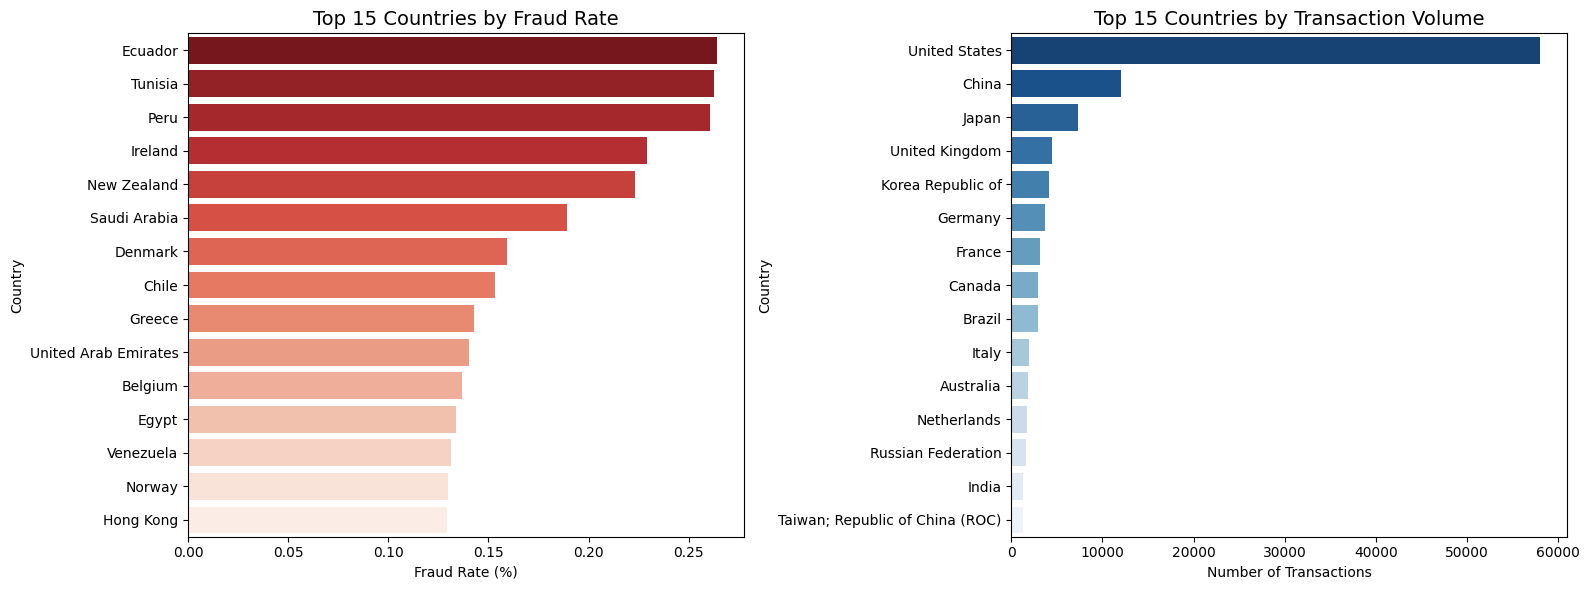


✓ Graphs saved to ../data/processed/fraud_country_analysis.png


In [27]:
#  Fraud by Country Analysis with Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate fraud rate by country (only countries with 100+ transactions)
country_stats = df_mapped.groupby('country').agg({
    'class': ['count', 'mean']
}).round(4)
country_stats.columns = ['total_transactions', 'fraud_rate']
country_stats = country_stats[country_stats['total_transactions'] >= 100]
country_stats = country_stats.sort_values('fraud_rate', ascending=False)

print("=" * 50)
print("TOP 15 COUNTRIES BY FRAUD RATE")
print("=" * 50)
print(country_stats.head(15))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Fraud Rate by Country
top_fraud = country_stats.head(15).reset_index()
sns.barplot(data=top_fraud, x='fraud_rate', y='country', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 15 Countries by Fraud Rate', fontsize=14)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Country')

# Plot 2: Transaction Volume by Country (Top 15)
top_volume = df_mapped['country'].value_counts().head(15)
sns.barplot(x=top_volume.values, y=top_volume.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 15 Countries by Transaction Volume', fontsize=14)
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.savefig('../data/processed/fraud_country_analysis.png', dpi=100)
plt.show()

print("\n✓ Graphs saved to ../data/processed/fraud_country_analysis.png")

7. Time Since Signup Feature

FRAUD RATE BY TIME SINCE SIGNUP
                  count  fraud_rate
signup_age_group                   
<30 min            6661   99.819847
30-60 min            24    8.333333
1-24 hours          972    3.806584
1-7 days           6064    4.534960
1-30 days         23494    4.443688
>30 days          91931    4.634998


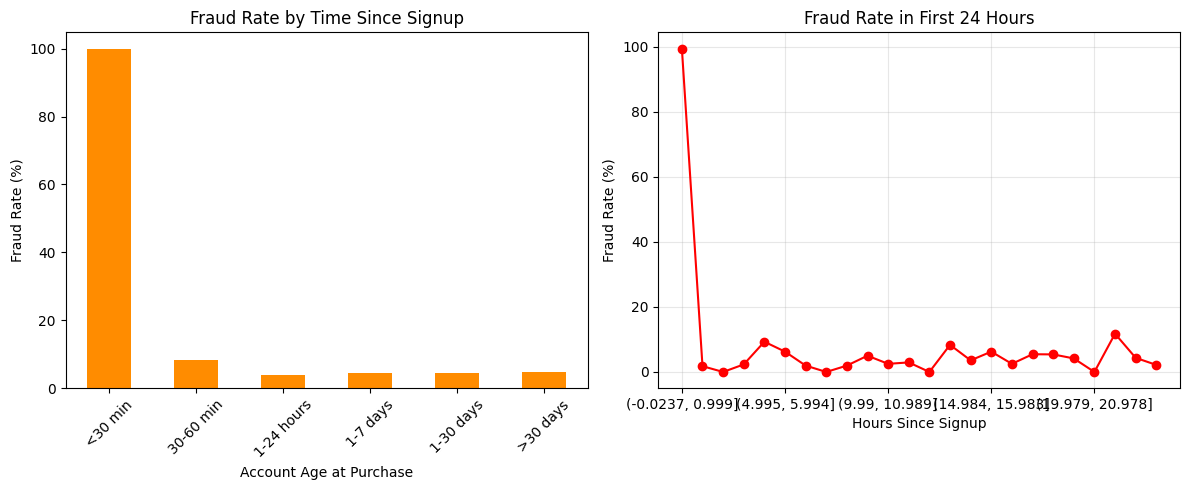


✓ Key Insight: Transactions within 1 hour of signup have 99.82% fraud rate


In [28]:
# Time Since Signup Feature Engineering
from datetime import timedelta

# Calculate time since signup in hours
df_mapped['time_since_signup_hours'] = (
    df_mapped['purchase_time'] - df_mapped['signup_time']
).dt.total_seconds() / 3600

# Also in minutes for fraud patterns
df_mapped['time_since_signup_minutes'] = (
    df_mapped['purchase_time'] - df_mapped['signup_time']
).dt.total_seconds() / 60

# Create age groups for analysis
df_mapped['signup_age_group'] = pd.cut(
    df_mapped['time_since_signup_hours'],
    bins=[0, 0.5, 1, 24, 168, 720, float('inf')],
    labels=['<30 min', '30-60 min', '1-24 hours', '1-7 days', '1-30 days', '>30 days']
)

# Analyze fraud rate by signup age
signup_fraud = df_mapped.groupby('signup_age_group')['class'].agg(['count', 'mean'])
signup_fraud['fraud_rate'] = signup_fraud['mean'] * 100
signup_fraud['count'] = signup_fraud['count']

print("=" * 50)
print("FRAUD RATE BY TIME SINCE SIGNUP")
print("=" * 50)
print(signup_fraud[['count', 'fraud_rate']])

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
signup_fraud['fraud_rate'].plot(kind='bar', color='darkorange')
plt.title('Fraud Rate by Time Since Signup', fontsize=12)
plt.xlabel('Account Age at Purchase')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Focus on first 24 hours
first_24h = df_mapped[df_mapped['time_since_signup_hours'] <= 24]
hourly_bins = pd.cut(first_24h['time_since_signup_hours'], bins=24)
hourly_fraud = first_24h.groupby(hourly_bins)['class'].mean() * 100
hourly_fraud.plot(kind='line', marker='o', color='red')
plt.title('Fraud Rate in First 24 Hours', fontsize=12)
plt.xlabel('Hours Since Signup')
plt.ylabel('Fraud Rate (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/fraud_by_signup_age.png', dpi=100)
plt.show()

print("\n✓ Key Insight: Transactions within 1 hour of signup have {:.2f}% fraud rate".format(
    signup_fraud.loc['<30 min', 'fraud_rate'] if '<30 min' in signup_fraud.index else 0
))

8. Transaction Velocity Features

In [29]:
# Transaction Velocity Features
print("Creating velocity features...")

# Sort by user and time
df_mapped = df_mapped.sort_values(['user_id', 'purchase_time'])

# Transaction count per user (overall)
df_mapped['user_total_transactions'] = df_mapped.groupby('user_id')['user_id'].transform('count')

# Transactions in last hour per user
df_mapped['transactions_last_hour'] = df_mapped.groupby('user_id')['purchase_time'].transform(
    lambda x: x.diff().dt.total_seconds().fillna(999999) < 3600
).astype(int)

# Transactions in last 24 hours (rolling count)
def count_last_24h(group):
    times = group['purchase_time'].values
    counts = []
    for i, t in enumerate(times):
        window_start = t - pd.Timedelta(hours=24)
        count = sum(1 for j in range(i) if times[j] >= window_start)
        counts.append(count)
    return counts

df_mapped['transactions_last_24h'] = df_mapped.groupby('user_id').apply(
    lambda g: pd.Series(count_last_24h(g), index=g.index)
).values

# Flag for multiple transactions
df_mapped['is_multiple_transactions'] = (df_mapped['user_total_transactions'] > 1).astype(int)

print("\nVelocity Statistics:")
print(f"  - Users with multiple transactions: {df_mapped['is_multiple_transactions'].sum():,}")
print(f"  - Avg transactions per user: {df_mapped['user_total_transactions'].mean():.2f}")
print(f"  - Max transactions in 24h: {df_mapped['transactions_last_24h'].max()}")
print(f"  - Fraud rate for rapid transactions: {df_mapped[df_mapped['transactions_last_hour']==1]['class'].mean():.4f}")

Creating velocity features...

Velocity Statistics:
  - Users with multiple transactions: 0
  - Avg transactions per user: 1.00
  - Max transactions in 24h: 0
  - Fraud rate for rapid transactions: nan


9. Device and Browser Features

In [30]:
# Device and Browser Features
print("Creating device and browser features...")

# Device frequency (how many users per device)
device_stats = df_mapped.groupby('device_id').agg({
    'user_id': 'nunique',
    'class': 'mean'
}).rename(columns={'user_id': 'users_per_device', 'class': 'device_fraud_rate'})

df_mapped = df_mapped.merge(device_stats, on='device_id', how='left')

# Browser features
df_mapped['is_chrome'] = (df_mapped['browser'] == 'Chrome').astype(int)
df_mapped['is_safari'] = (df_mapped['browser'] == 'Safari').astype(int)
df_mapped['is_firefox'] = (df_mapped['browser'] == 'Firefox').astype(int)

# Source features
df_mapped['is_seo'] = (df_mapped['source'] == 'SEO').astype(int)
df_mapped['is_ads'] = (df_mapped['source'] == 'Ads').astype(int)

print("\nDevice Statistics:")
print(f"  - Shared devices (multiple users): {(device_stats['users_per_device'] > 1).sum():,}")
print(f"  - Fraud rate on shared devices: {df_mapped[df_mapped['users_per_device'] > 1]['class'].mean():.4f}")
print(f"  - Fraud rate on unique devices: {df_mapped[df_mapped['users_per_device'] == 1]['class'].mean():.4f}")

Creating device and browser features...

Device Statistics:
  - Shared devices (multiple users): 4,622
  - Fraud rate on shared devices: 0.5551
  - Fraud rate on unique devices: 0.0330


10. Time Features & Final Dataset

In [31]:
#  Time Features and Final Dataset Preparation

# Extract time features from purchase_time
df_mapped['hour_of_day'] = df_mapped['purchase_time'].dt.hour
df_mapped['day_of_week'] = df_mapped['purchase_time'].dt.dayofweek
df_mapped['month'] = df_mapped['purchase_time'].dt.month
df_mapped['is_weekend'] = (df_mapped['day_of_week'] >= 5).astype(int)
df_mapped['is_night'] = ((df_mapped['hour_of_day'] >= 22) | (df_mapped['hour_of_day'] <= 5)).astype(int)

# Select final features for modeling
features_to_keep = [
    'purchase_value',
    'age',
    'time_since_signup_hours',
    'transactions_last_hour',
    'transactions_last_24h',
    'user_total_transactions',
    'users_per_device',
    'device_fraud_rate',
    'hour_of_day',
    'day_of_week',
    'month',
    'is_weekend',
    'is_night',
    'is_chrome',
    'is_safari',
    'is_firefox',
    'is_seo',
    'is_ads',
    'class'  # target
]

# Add country one-hot encoding
country_dummies = pd.get_dummies(df_mapped['country'], prefix='country', drop_first=True)
# Keep only top 20 countries to avoid too many columns
top_countries = df_mapped['country'].value_counts().head(20).index
country_dummies_top = country_dummies[[col for col in country_dummies.columns 
                                        if any(country in col for country in top_countries)]]

# Combine all features
df_final = pd.concat([
    df_mapped[features_to_keep],
    country_dummies_top
], axis=1)

# Remove any infinite values
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

print("=" * 50)
print("FINAL DATASET READY")
print("=" * 50)
print(f"Shape: {df_final.shape}")
print(f"Features: {len(df_final.columns) - 1}")
print(f"Fraud rate: {df_final['class'].mean():.4f}")
print(f"\nFeatures created: {df_final.columns.tolist()[:15]}...")

FINAL DATASET READY
Shape: (129146, 40)
Features: 39
Fraud rate: 0.0950

Features created: ['purchase_value', 'age', 'time_since_signup_hours', 'transactions_last_hour', 'transactions_last_24h', 'user_total_transactions', 'users_per_device', 'device_fraud_rate', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_night', 'is_chrome', 'is_safari']...


11. Save Engineering Datasets

In [32]:
# Save for Modeling

import joblib

# Separate features and target
X_fraud = df_final.drop('class', axis=1)
y_fraud = df_final['class']

# Save to processed folder
joblib.dump(X_fraud, '../data/processed/X_fraud.pkl')
joblib.dump(y_fraud, '../data/processed/y_fraud.pkl')

# Also save CSV for inspection
df_final.to_csv('../data/processed/fraud_engineered_features.csv', index=False)

print("✓ Saved to ../data/processed/")
print(f"  - X_fraud.pkl: {X_fraud.shape}")
print(f"  - y_fraud.pkl: {y_fraud.shape}")
print(f"  - fraud_engineered_features.csv: {df_final.shape}")

# Quick statistics
print("\n" + "=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total samples: {len(df_final):,}")
print(f"Fraud samples: {y_fraud.sum():,} ({y_fraud.mean()*100:.2f}%)")
print(f"Legitimate samples: {(y_fraud==0).sum():,}")
print(f"Number of features: {X_fraud.shape[1]}")

✓ Saved to ../data/processed/
  - X_fraud.pkl: (129146, 39)
  - y_fraud.pkl: (129146,)
  - fraud_engineered_features.csv: (129146, 40)

DATASET SUMMARY
Total samples: 129,146
Fraud samples: 12,268 (9.50%)
Legitimate samples: 116,878
Number of features: 39
